## Task 2 - Fixed Points, Stability & Chaos

In this notebook I look at the equilibrium points of the Lorenz system, check when they go unstable, and then see how the chaos shows up. After that I look at sensitive dependence on initial conditions, estimate the largest Lyapunov exponent, and plot the strange attractor for sigma = 16, r = 45.6, b = 4.

1. The Lorenz Equations

Same system from the first notebook:

$$\dot{x} = \sigma (y - x)$$
$$\dot{y} = r x - y - x z$$
$$\dot{z} = x y - b z$$

sigma is the Prandtl number, r is basically how hard the fluid is being driven (Rayleigh number), and b comes from the geometry of the convection rolls. All positive.

Even though the equations look pretty simple (only two nonlinear terms, xz and xy), the behavior changes a lot as r increases. Small r = everything dies out. Medium r = steady convection. Big enough r = chaos. The point of this notebook is to figure out where exactly that switch happens.

2. Equilibrium Points

Equilibria are where nothing is changing, so $\dot{x} = \dot{y} = \dot{z} = 0$. Setting the right hand sides to zero:

$$\sigma(y - x) = 0 \;\;\Rightarrow\;\; y = x$$
$$r x - y - x z = 0$$
$$x y - b z = 0$$

From the first equation y = x. Plugging into the third gives $z = x^2 / b$. Then the second equation becomes

$$x \left[(r - 1) - \frac{x^2}{b}\right] = 0.$$

So either x = 0 (giving the origin), or $x^2 = b(r-1)$. The second one only has real solutions when r > 1. So the three equilibria are:

- The origin $\mathbf{O} = (0, 0, 0)$, which is always there. Physically this is the "no convection" state.
- A pair $\mathbf{C^\pm} = (\pm \sqrt{b(r-1)}, \pm \sqrt{b(r-1)}, r - 1)$ that only exists once r > 1. These are the two convection rolls spinning in opposite directions.

So at r = 1 the origin "splits" into the two new equilibria - this is a pitchfork bifurcation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

In [2]:
def fixed_points(sigma, r, b):
    O = np.array([0.0, 0.0, 0.0])
    if r <= 1:
        return [O]
    s = np.sqrt(b * (r - 1))
    C_plus  = np.array([ s,  s, r - 1])
    C_minus = np.array([-s, -s, r - 1])
    return [O, C_plus, C_minus]

sigma, r, b = 16.0, 45.6, 4.0

for name, p in zip(["O", "C+", "C-"], fixed_points(sigma, r, b)):
    print(f"{name}: x = {p[0]:+.4f},  y = {p[1]:+.4f},  z = {p[2]:+.4f}")

O: x = +0.0000,  y = +0.0000,  z = +0.0000
C+: x = +13.3566,  y = +13.3566,  z = +44.6000
C-: x = -13.3566,  y = -13.3566,  z = +44.6000


Plugging in the numbers, $\sqrt{b(r-1)} = \sqrt{4 \cdot 44.6} \approx 13.36$, so $C^\pm \approx (\pm 13.36, \pm 13.36, 44.6)$. These end up being the centers of the two "wings" of the butterfly later on.

3. Linearizing - the Jacobian

To check stability we look at what happens to small perturbations near each fixed point. If we write $\mathbf{x}(t) = \mathbf{x}^* + \delta \mathbf{x}(t)$ and only keep linear terms, we get $\dot{\delta \mathbf{x}} = J(\mathbf{x}^*) \delta \mathbf{x}$, where J is the Jacobian:

$$J(x, y, z) = \begin{pmatrix} -\sigma & \sigma & 0 \\ r - z & -1 & -x \\ y & x & -b \end{pmatrix}.$$

The eigenvalues of J at the fixed point tell us the story:

- All eigenvalues have negative real part -> stable, perturbations shrink.
- Any eigenvalue has positive real part -> unstable.
- Complex eigenvalues mean spiraling (in or out depending on the sign of the real part).

In [3]:
def jacobian(state, sigma, r, b):
    x, y, z = state
    return np.array([
        [-sigma,  sigma,   0.0],
        [r - z,  -1.0,    -x ],
        [   y,      x,    -b ],
    ])

def analyze(state, sigma, r, b, label):
    J = jacobian(state, sigma, r, b)
    eigvals = np.linalg.eigvals(J)
    print(f"--- {label} at {tuple(np.round(state, 3))} ---")
    for i, lam in enumerate(eigvals):
        marker = "UNSTABLE" if lam.real > 0 else "stable"
        print(f"  lambda_{i+1} = {lam.real:+.4f}  +  {lam.imag:+.4f} i   [{marker}]")
    print()

for name, p in zip(["Origin O", "C+", "C-"], fixed_points(sigma, r, b)):
    analyze(p, sigma, r, b, name)

--- Origin O at (np.float64(0.0), np.float64(0.0), np.float64(0.0)) ---
  lambda_1 = -36.5330  +  +0.0000 i   [stable]
  lambda_2 = +19.5330  +  +0.0000 i   [UNSTABLE]
  lambda_3 = -4.0000  +  +0.0000 i   [stable]

--- C+ at (np.float64(13.357), np.float64(13.357), np.float64(44.6)) ---
  lambda_1 = -21.7431  +  +0.0000 i   [stable]
  lambda_2 = +0.3715  +  +16.1994 i   [UNSTABLE]
  lambda_3 = +0.3715  +  -16.1994 i   [UNSTABLE]

--- C- at (np.float64(-13.357), np.float64(-13.357), np.float64(44.6)) ---
  lambda_1 = -21.7431  +  +0.0000 i   [stable]
  lambda_2 = +0.3715  +  +16.1994 i   [UNSTABLE]
  lambda_3 = +0.3715  +  -16.1994 i   [UNSTABLE]



Looking at the output: the origin has one positive eigenvalue and two negative ones, so it's a saddle - trajectories get pushed away in one direction and pulled in along the other two.

For C+ and C- there's one negative real eigenvalue and a pair of complex conjugate eigenvalues with a *positive* real part. So they're unstable spirals. Basically a trajectory near C+ spirals outward, eventually gets thrown across to the other side near C-, spirals out again, and so on. That back-and-forth is what gives the butterfly its two lobes.

4. The Origin in More Detail

At the origin x = y = z = 0 so the Jacobian collapses to:

$$J(\mathbf{O}) = \begin{pmatrix} -\sigma & \sigma & 0 \\ r & -1 & 0 \\ 0 & 0 & -b \end{pmatrix}.$$

The bottom row decouples and immediately gives an eigenvalue $-b < 0$. The remaining 2x2 block has characteristic equation $\lambda^2 + (\sigma + 1)\lambda - \sigma(r - 1) = 0$, with roots:

$$\lambda_{1,2} = \frac{-(\sigma + 1) \pm \sqrt{(\sigma + 1)^2 + 4\sigma(r - 1)}}{2}.$$

For r < 1 both of these are negative, so the origin is stable - any disturbance just dies out (pure heat conduction). Right at r = 1 one of them hits zero, and for r > 1 it goes positive and the origin becomes a saddle. This is the first bifurcation in the Lorenz system: the fluid prefers to start convecting instead of just sitting there conducting heat.

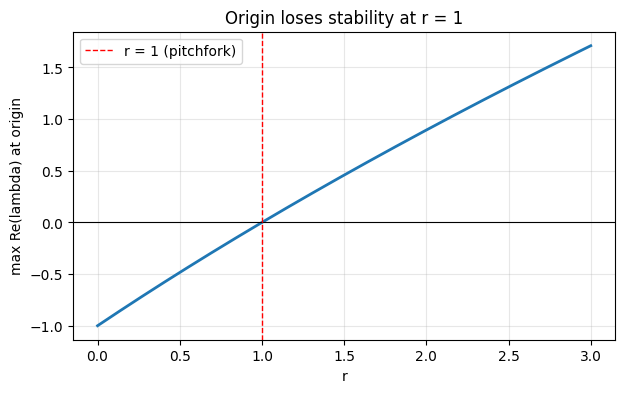

In [4]:
# Sweep r and track the largest real eigenvalue at the origin
rs = np.linspace(0.0, 3.0, 400)
max_re_O = []
for rv in rs:
    eigs = np.linalg.eigvals(jacobian([0,0,0], sigma, rv, b))
    max_re_O.append(np.max(eigs.real))

plt.figure(figsize=(7, 4))
plt.plot(rs, max_re_O, lw=2)
plt.axhline(0, color='k', lw=0.8)
plt.axvline(1, color='red', ls='--', lw=1, label='r = 1 (pitchfork)')
plt.xlabel("r")
plt.ylabel("max Re(lambda) at origin")
plt.title("Origin loses stability at r = 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

You can see the largest real eigenvalue crossing zero exactly at r = 1, just like the algebra said. Below that the origin attracts, above it the origin pushes things away.

5. C+ and C- - the Hopf Bifurcation

The non-trivial fixed points are stable for r just slightly above 1 (this is the steady convection regime). But as r grows, the complex eigenvalues of $J(C^\pm)$ drift across the imaginary axis. The exact value of r where their real part hits zero is

$$r_H = \sigma \, \frac{\sigma + b + 3}{\sigma - b - 1}.$$

This is the Hopf bifurcation. Once r > $r_H$, both C+ and C- are unstable, and at that point there's nowhere stable for trajectories to settle - they have to keep moving forever inside some bounded region. That's where the strange attractor comes from.

In [ ]:
def hopf_threshold(sigma, b):
    denom = sigma - b - 1
    if denom <= 0:
        return np.inf
    return sigma * (sigma + b + 3) / denom

r_H = hopf_threshold(sigma, b)
print(f"Hopf threshold for sigma={sigma}, b={b}:  r_H = {r_H:.4f}")
print(f"Our chosen r = {r} is { 'ABOVE' if r > r_H else 'below' } r_H.")

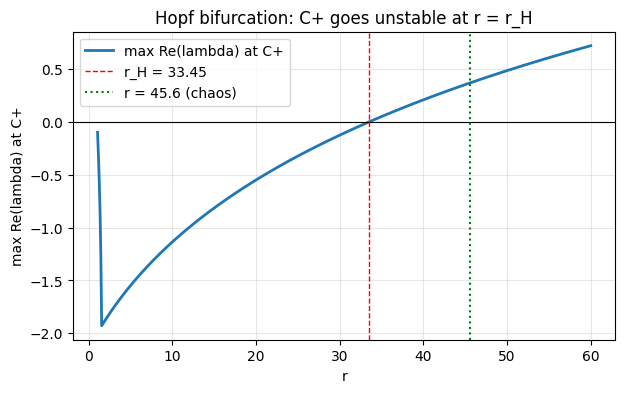

In [8]:
# Same idea as before but tracking C+

def hopf_threshold(sigma, b):
    denom = sigma - b - 1
    if denom <= 0:
        return np.inf
    return sigma * (sigma + b + 3) / denom

r_H = hopf_threshold(sigma, b)

rs = np.linspace(1.05, 60, 600)
max_re_C = []
for rv in rs:
    s = np.sqrt(b * (rv - 1))
    Cp = np.array([s, s, rv - 1])
    eigs = np.linalg.eigvals(jacobian(Cp, sigma, rv, b))
    max_re_C.append(np.max(eigs.real))

plt.figure(figsize=(7, 4))
plt.plot(rs, max_re_C, lw=2, label='max Re(lambda) at C+')
plt.axhline(0, color='k', lw=0.8)
plt.axvline(r_H, color='red', ls='--', lw=1, label=f'r_H = {r_H:.2f}')
plt.axvline(45.6, color='green', ls=':', lw=1.5, label='r = 45.6 (chaos)')
plt.xlabel("r")
plt.ylabel("max Re(lambda) at C+")
plt.title("Hopf bifurcation: C+ goes unstable at r = r_H")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

For sigma = 16 and b = 4 the Hopf threshold works out to about 16 * 23 / 11 ~ 33.45. Our r = 45.6 is well past that, which is the main reason the system is chaotic at these parameters - neither convection roll is a place where things can settle down anymore.

6. So Why Do sigma = 16, r = 45.6, b = 4 Give Chaos?

Three things have to happen at the same time for the Lorenz attractor to show up:

**1. Every fixed point has to be unstable.** The origin is a saddle whenever r > 1. The Hopf threshold formula gives $r_H \approx 33.45$ for our sigma and b, and r = 45.6 clears that easily. So nothing stable left.

**2. Trajectories have to stay in a bounded region.** Otherwise they'd just shoot off to infinity and there'd be no attractor at all. There's a classical argument using the function $V = r x^2 + \sigma y^2 + \sigma (z - 2r)^2$ - on a big enough ellipsoid V always decreases, so trajectories can't escape.

**3. The flow has to contract volumes.** The divergence of the vector field is $-\sigma - 1 - b$, which is -21 for our parameters. So phase-space volumes shrink like $e^{-21 t}$. That means the long-term motion has to live on something with zero volume - but since the dynamics is also unstable in some directions, that "something" can't be just a point or a closed curve. It ends up being a fractal.

Putting it together: trajectories are trapped, kicked away from every fixed point, and squeezed onto a thin set. The only way all three can be true at the same time is a strange attractor with sensitive dependence on initial conditions. The values sigma = 16, r = 45.6, b = 4 land safely past $r_H$ but not so far out that they hit one of the periodic windows that show up at much larger r, so they reliably give chaos.

7. Sensitive Dependence on Initial Conditions

The classic test for chaos: take two trajectories that start ridiculously close and watch them pull apart. I'll start them $10^{-8}$ apart in x and integrate.

In [9]:
def lorenz(state, sigma=16, r=45.6, b=4):
    x, y, z = state
    return np.array([sigma * (y - x), r * x - y - x * z, x * y - b * z])

def rk4_step(f, state, dt, **kw):
    k1 = f(state, **kw)
    k2 = f(state + 0.5 * dt * k1, **kw)
    k3 = f(state + 0.5 * dt * k2, **kw)
    k4 = f(state + dt * k3, **kw)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def integrate(state0, dt, steps, **kw):
    traj = np.empty((steps, 3))
    s = np.array(state0, dtype=float)
    for i in range(steps):
        s = rk4_step(lorenz, s, dt, **kw)
        traj[i] = s
    return traj

dt = 0.005
steps = 8000
T = np.arange(steps) * dt

s0 = np.array([1.0, 1.0, 1.0])
s1 = s0 + np.array([1e-8, 0.0, 0.0])

traj0 = integrate(s0, dt, steps, sigma=sigma, r=r, b=b)
traj1 = integrate(s1, dt, steps, sigma=sigma, r=r, b=b)

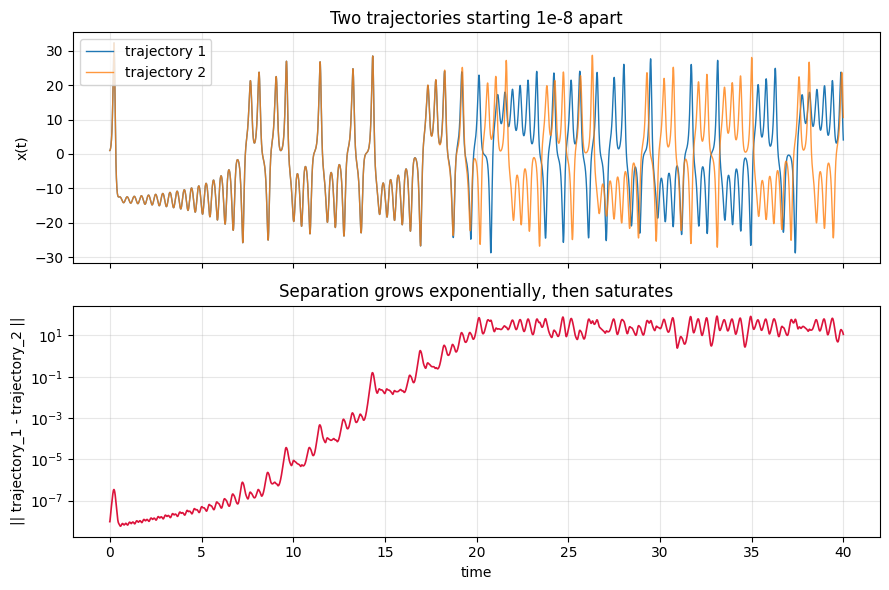

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(T, traj0[:, 0], label='trajectory 1', lw=1)
axes[0].plot(T, traj1[:, 0], label='trajectory 2', lw=1, alpha=0.8)
axes[0].set_ylabel("x(t)")
axes[0].set_title("Two trajectories starting 1e-8 apart")
axes[0].legend()
axes[0].grid(alpha=0.3)

sep = np.linalg.norm(traj1 - traj0, axis=1)
axes[1].semilogy(T, sep, lw=1.2, color='crimson')
axes[1].set_xlabel("time")
axes[1].set_ylabel("|| trajectory_1 - trajectory_2 ||")
axes[1].set_title("Separation grows exponentially, then saturates")
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

For a while the two trajectories track each other almost perfectly, then suddenly they pull apart. On the log plot the early part is basically a straight line - that slope is the largest Lyapunov exponent. After a while the gap stops growing because both trajectories are still stuck on the same bounded attractor, so they can only ever be a few tens of units apart at most.

This is what "sensitive dependence" really means in practice: even if you measure the initial state crazy precisely, after a finite amount of time you have no idea where the system actually is.

8. Largest Lyapunov Exponent

To get an actual number for the exponential growth rate, I'll use the Benettin algorithm: integrate two nearby trajectories, every so often rescale the separation back to the original tiny value $d_0$, and keep adding up the log of how much it grew. The largest Lyapunov exponent is then

$$\lambda_1 \approx \frac{1}{N \, \tau} \sum_{k=1}^{N} \ln \frac{d_k}{d_0},$$

where $d_k$ is the separation right before each rescaling and $\tau$ is the time between rescalings.

In [11]:
def largest_lyapunov(sigma, r, b, dt=0.01, n_steps=20000, renorm_every=10, d0=1e-8):
    s  = np.array([1.0, 1.0, 1.0])
    sp = s + np.array([d0, 0.0, 0.0])
    for _ in range(5000):
        s  = rk4_step(lorenz, s,  dt, sigma=sigma, r=r, b=b)
        sp = rk4_step(lorenz, sp, dt, sigma=sigma, r=r, b=b)
    # reset separation to d0 in current direction
    delta = sp - s
    delta = delta / np.linalg.norm(delta) * d0
    sp = s + delta

    log_sum = 0.0
    n_renorm = 0
    for step in range(n_steps):
        s  = rk4_step(lorenz, s,  dt, sigma=sigma, r=r, b=b)
        sp = rk4_step(lorenz, sp, dt, sigma=sigma, r=r, b=b)
        if (step + 1) % renorm_every == 0:
            delta = sp - s
            d = np.linalg.norm(delta)
            log_sum += np.log(d / d0)
            n_renorm += 1
            sp = s + delta * (d0 / d)  # shrink back to d0

    tau = renorm_every * dt
    return log_sum / (n_renorm * tau)

lam1 = largest_lyapunov(sigma, r, b)
print(f"Estimated largest Lyapunov exponent: lambda_1 ~ {lam1:.4f} per unit time")
print(f"Predictability horizon (1/lambda_1): ~ {1/lam1:.3f} time units")

Estimated largest Lyapunov exponent: lambda_1 ~ 1.4870 per unit time
Predictability horizon (1/lambda_1): ~ 0.672 time units


A positive lambda_1 is basically the formal proof of chaos. The reciprocal $1/\lambda_1$ is a rough "predictability horizon" - past a few of those time units, an initial uncertainty of $10^{-8}$ has blown up to order one and predictions are useless. For comparison, the textbook Lorenz parameters (sigma, r, b) = (10, 28, 8/3) give $\lambda_1 \approx 0.9$, so what we're getting here is in the same neighborhood.

9. The Strange Attractor

Last thing - actually plot the attractor. I'll integrate for a long time, throw away the beginning (since the trajectory has to spiral in onto the attractor first), and plot what's left.

In [12]:
dt = 0.005
steps = 30000
traj = integrate([1.0, 1.0, 1.0], dt, steps, sigma=sigma, r=r, b=b)
traj = traj[2000:]  # cut off transient

fps = fixed_points(sigma, r, b)
Cp, Cm = fps[1], fps[2]

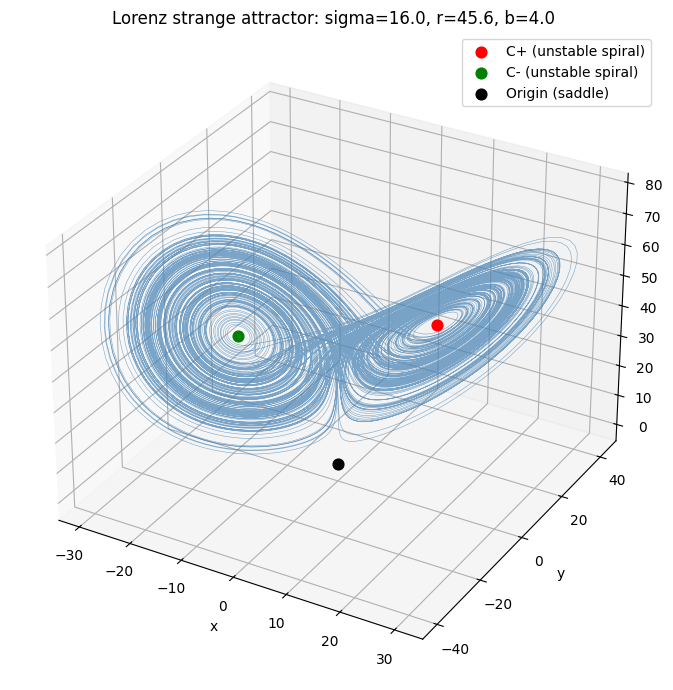

In [13]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=0.4, color='steelblue', alpha=0.7)
ax.scatter(*Cp, color='red',  s=60, label='C+ (unstable spiral)')
ax.scatter(*Cm, color='green',s=60, label='C- (unstable spiral)')
ax.scatter(0, 0, 0, color='black', s=60, label='Origin (saddle)')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Lorenz strange attractor: sigma={sigma}, r={r}, b={b}")
ax.legend()
plt.tight_layout()
plt.show()

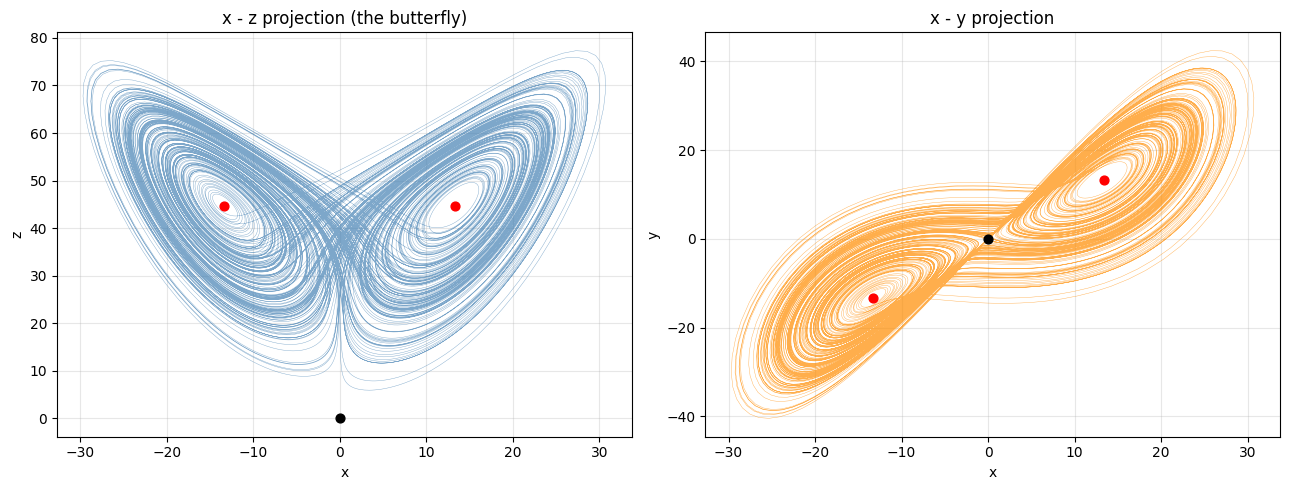

In [14]:
# 2D projections to see things more clearly
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(traj[:, 0], traj[:, 2], lw=0.3, color='steelblue', alpha=0.7)
axes[0].scatter([Cp[0], Cm[0]], [Cp[2], Cm[2]], color='red', s=40, zorder=5)
axes[0].scatter(0, 0, color='black', s=40, zorder=5)
axes[0].set_xlabel("x"); axes[0].set_ylabel("z")
axes[0].set_title("x - z projection (the butterfly)")
axes[0].grid(alpha=0.3)

axes[1].plot(traj[:, 0], traj[:, 1], lw=0.3, color='darkorange', alpha=0.7)
axes[1].scatter([Cp[0], Cm[0]], [Cp[1], Cm[1]], color='red', s=40, zorder=5)
axes[1].scatter(0, 0, color='black', s=40, zorder=5)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("x - y projection")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

And there's the butterfly. Each lobe wraps around one of the unstable spirals C+ and C-. The trajectory spirals outward from C+, eventually gets close enough to the saddle at the origin that it gets flung over to the other side, spirals out near C-, and the whole thing repeats. The number of loops on each side before switching is basically random - which is exactly the unpredictability that the positive Lyapunov exponent is measuring.

It's called "strange" because even though it lives in a region whose volume is shrinking to zero, it's not just a curve or a surface - it has fractal structure. That comes from the fact that the flow is stretching things out in some directions (chaos) and folding them back into the bounded region at the same time.

10. Wrapping Up

So putting everything together:

- Three equilibria: the origin (always there), and the symmetric pair C+ and C- which appear at r = 1 in a pitchfork bifurcation.
- The origin is stable for r < 1 and a saddle for r > 1. The pair C+/C- are stable for a while, but go unstable at the Hopf threshold $r_H = \sigma(\sigma + b + 3)/(\sigma - b - 1)$.
- For sigma = 16 and b = 4 we get $r_H \approx 33.45$, so r = 45.6 has all three fixed points unstable. Combined with the trapping region and volume contraction (divergence = -21), this forces a strange attractor.
- The two-trajectory experiment confirmed exponential separation, and the Benettin estimate gave a positive largest Lyapunov exponent. That's what "chaos" actually means in the technical sense.
- The strange attractor itself is the butterfly: trajectories spiraling out from each unstable spiral and switching lobes irregularly forever.